# 00 — Exploración del dataset crudo (`public`)

## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.db import read_sql

In [2]:
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
PALETTE = sns.color_palette('crest', as_cmap=False)

## 1. Inventario del esquema `public`

Listamos las tablas existentes y contamos sus filas para tener una visión global del volumen de datos.

### 1.1. Listado de tablas — SQL

In [3]:
%%sql
select table_name
from information_schema.tables
where table_schema = 'public'
order by table_name

,table_name
0,brand
1,category
2,central_inventory
3,central_product
4,city_zone
5,customer
6,inventory
7,offer
8,product
9,product_offer


### 1.2. Conteo de filas por tabla — Python

Recorremos los nombres devueltos por la consulta y lanzamos un `count(*)` para cada uno.

In [4]:
table_names = tables_raw['table_name'].tolist()

table_counts = pd.DataFrame(
    [(t, read_sql(f'select count(*) as n from public."{t}"')['n'][0]) for t in table_names],
    columns=['table', 'rows']
).sort_values('rows', ascending=False).reset_index(drop=True)

table_counts

,table,rows
0,sale_item,42555
1,sale,20000
2,customer,5750
3,return_item,2330
4,inventory,1000
5,product,50
6,central_inventory,49
7,central_product,49
8,city_zone,42
9,warehouse_location,40


## 2. Esquema: columnas y tipos

Inspeccionamos la cardinalidad de columnas, los tipos predominantes y la nulabilidad declarada en el catálogo.

### 2.1. Columnas por tabla — SQL

In [5]:
%%sql
select table_name, column_name, data_type, is_nullable
from information_schema.columns
where table_schema = 'public'
order by table_name, ordinal_position

,table_name,column_name,data_type,is_nullable
0,brand,brand_id,integer,NO
1,brand,name,character varying,NO
2,brand,country,character varying,YES
3,brand,website,character varying,YES
4,category,category_id,integer,NO
...,...,...,...,...
91,warehouse_location,warehouse_id,integer,YES
92,warehouse_location,zone,character varying,YES
93,warehouse_location,aisle,character varying,YES
94,warehouse_location,shelf,character varying,YES


### 2.2. Resumen agregado por tabla — Python

In [6]:
schema_summary = (
    columns_raw
    .assign(nullable=lambda d: (d['is_nullable'] == 'YES').astype(int))
    .groupby('table_name')
    .agg(n_cols=('column_name', 'count'),
         n_nullable=('nullable', 'sum'))
    .assign(pct_nullable=lambda d: (d['n_nullable'] / d['n_cols'] * 100).round(1))
    .sort_values('n_cols', ascending=False)
)
schema_summary

,n_cols,n_nullable,pct_nullable
table_name,,,
central_inventory,8,6,75.0
central_product,8,6,75.0
store,8,6,75.0
sale_item,7,3,42.9
warehouse,7,5,71.4
customer,7,6,85.7
product,6,3,50.0
warehouse_location,6,5,83.3
offer,6,3,50.0


### 2.4. Distribución global de tipos de dato

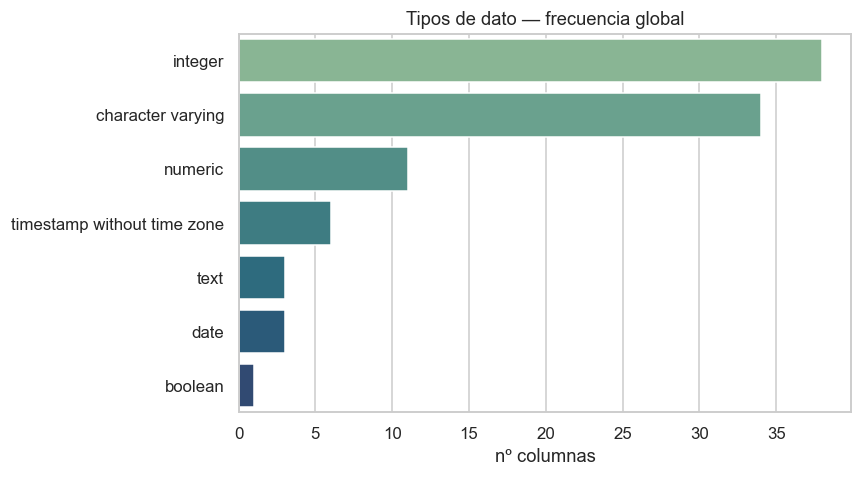

In [7]:
type_counts = columns_raw['data_type'].value_counts().reset_index()
type_counts.columns = ['data_type', 'n']

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=type_counts, x='n', y='data_type', hue='data_type',
            palette='crest', ax=ax, legend=False)
ax.set_title('Tipos de dato — frecuencia global')
ax.set_xlabel('nº columnas')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Cobertura temporal

Comprobamos los rangos de fechas presentes en `sale` y `return_item` para definir la ventana de análisis.

### 3.1. Rango de ventas — SQL

In [8]:
%%sql
select min(sale_date) as min_date,
       max(sale_date) as max_date,
       count(*)       as n
from public.sale

,min_date,max_date,n
0,2020-01-01 03:41:35.198837,2025-12-30 23:52:53.702142,20000


### 3.2. Rango de devoluciones — SQL

In [9]:
%%sql
select min(return_date) as min_date,
       max(return_date) as max_date,
       count(*)         as n
from public.return_item

,min_date,max_date,n
0,2020-01-09 15:12:41.444797,2026-02-07 02:02:05.028517,2330


### 3.3. Visualización — timeline de cobertura

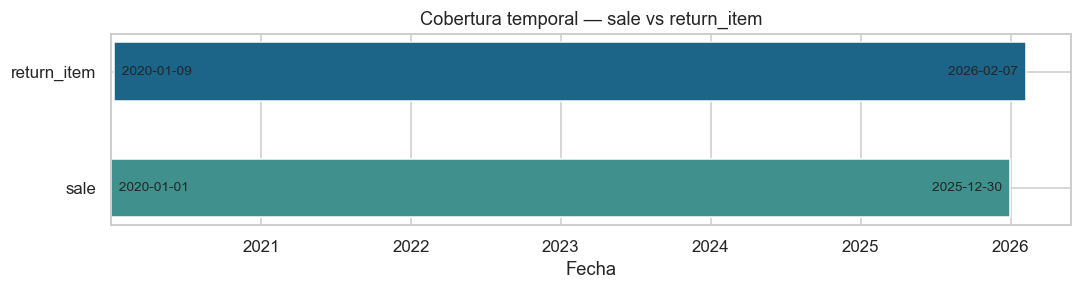

,tabla,inicio,fin,duracion_dias
0,sale,2020-01-01 03:41:35.198837,2025-12-30 23:52:53.702142,2190
1,return_item,2020-01-09 15:12:41.444797,2026-02-07 02:02:05.028517,2220


In [10]:
ranges = pd.DataFrame({
    'tabla': ['sale', 'return_item'],
    'inicio': pd.to_datetime([sales_range['min_date'][0], returns_range['min_date'][0]]),
    'fin':    pd.to_datetime([sales_range['max_date'][0], returns_range['max_date'][0]]),
})
ranges['duracion_dias'] = (ranges['fin'] - ranges['inicio']).dt.days

fig, ax = plt.subplots(figsize=(10, 2.8))
for i, (_, row) in enumerate(ranges.iterrows()):
    ax.barh(row['tabla'], row['duracion_dias'], left=row['inicio'],
            color=PALETTE[2 + i * 2], height=0.5)
    ax.text(row['inicio'], i, f"  {row['inicio'].date()}", va='center', fontsize=9)
    ax.text(row['fin'], i, f"{row['fin'].date()}  ", va='center', ha='right', fontsize=9)
ax.set_title('Cobertura temporal — sale vs return_item')
ax.set_xlabel('Fecha')
plt.tight_layout()
plt.show()

ranges

## 4. Distribución temporal de ventas

Vemos cómo se reparten los 20 000 tickets a lo largo del periodo cubierto.

### 4.1. Ventas agregadas por mes — SQL

In [11]:
%%sql
select date_trunc('month', sale_date)::date as month,
       count(*)                              as n_sales
from public.sale
group by 1
order by 1

,month,n_sales
0,2020-01-01,223
1,2020-02-01,177
2,2020-03-01,231
3,2020-04-01,220
4,2020-05-01,191
...,...,...
67,2025-08-01,203
68,2025-09-01,685
69,2025-10-01,694
70,2025-11-01,457


### 4.2. Visualización — serie mensual y heatmap año × mes

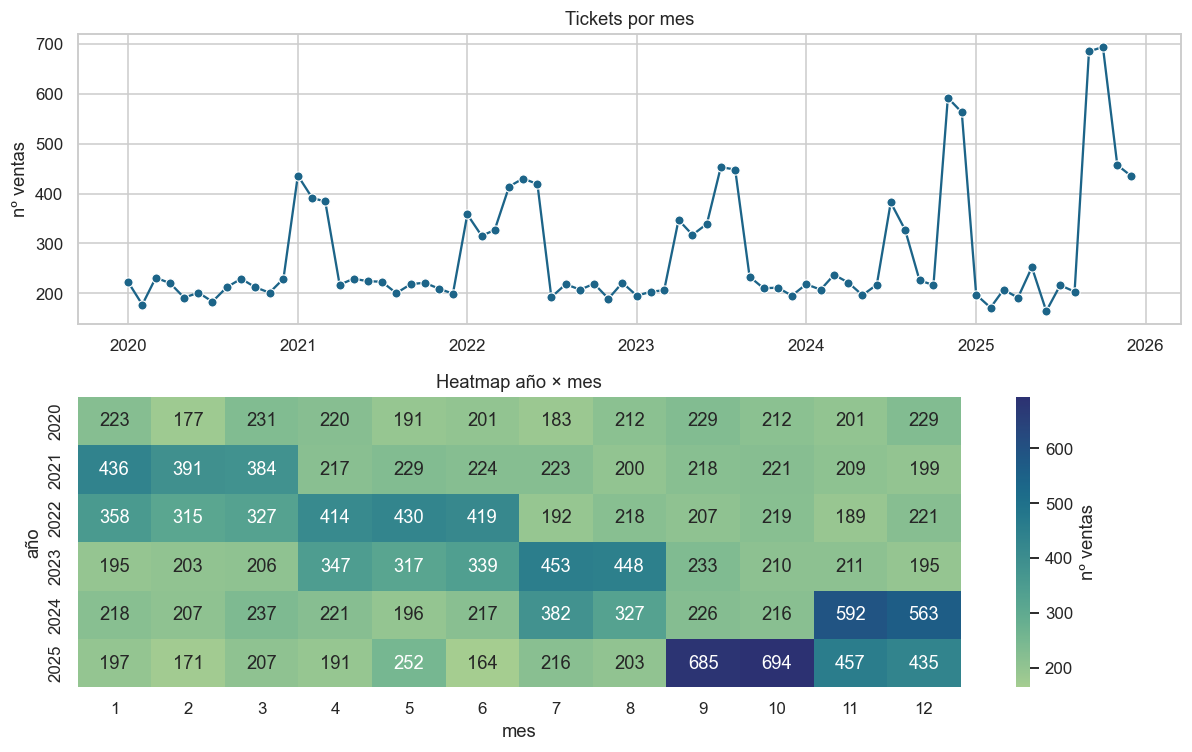

In [12]:
spm = sales_per_month.copy()
spm['month'] = pd.to_datetime(spm['month'])
spm['year'] = spm['month'].dt.year
spm['month_num'] = spm['month'].dt.month

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

sns.lineplot(data=spm, x='month', y='n_sales', marker='o',
             color=PALETTE[4], ax=axes[0])
axes[0].set_title('Tickets por mes')
axes[0].set_xlabel('')
axes[0].set_ylabel('nº ventas')

heat = spm.pivot(index='year', columns='month_num', values='n_sales')
sns.heatmap(heat, annot=True, fmt='.0f', cmap='crest', ax=axes[1],
            cbar_kws={'label': 'nº ventas'})
axes[1].set_title('Heatmap año × mes')
axes[1].set_xlabel('mes')
axes[1].set_ylabel('año')

plt.tight_layout()
plt.show()

## 5. Calidad de datos

Buscamos inconsistencias aritméticas y nulos en la tabla de clientes para anticipar reglas de limpieza en staging.

### 5.1. Subtotales inconsistentes en `sale_item` — SQL

Detectamos filas donde `subtotal <> quantity * unit_price`.

In [13]:
%%sql
select sum((subtotal <> quantity * unit_price)::int) as bad_subtotal,
       count(*)                                       as total
from public.sale_item

,bad_subtotal,total
0,8,42555


### 5.3. Nulos en `customer` — SQL

Contamos nulos por columna en una de las tablas con más volumen.

In [14]:
%%sql
select count(*)                                                  as n_total,
       count(*) filter (where first_name  is null) as null_first_name,
       count(*) filter (where last_name   is null) as null_last_name,
       count(*) filter (where email       is null) as null_email,
       count(*) filter (where phone       is null) as null_phone
from public.customer

,n_total,null_first_name,null_last_name,null_email,null_phone
0,5750,0,0,0,0


## 6. Solapamiento `product` / `central_product`

Verificamos si todos los productos vendidos están registrados también en el catálogo central.

### 6.1. Conteos y diferencias — SQL

In [15]:
%%sql
select (select count(*) from public.product)         as n_product,
       (select count(*) from public.central_product) as n_central,
       (select count(*)
        from public.product p
        where not exists (select 1
                          from public.central_product c
                          where c.product_id = p.product_id)) as only_in_product,
       (select count(*)
        from public.central_product c
        where not exists (select 1
                          from public.product p
                          where p.product_id = c.product_id)) as only_in_central

,n_product,n_central,only_in_product,only_in_central
0,50,49,1,0
